In [47]:
import numpy as np
import matplotlib.pyplot as plt

## Functions
### Wu-Schaback radial basis function
$$\varphi(r) = \frac{s^2}{(s^2 + r^2)^{3/2}} $$

where $\emph{s}$ is a shape parameter.

### Multiquadric basis function
$$ \phi_i(z) = \sqrt{c^2 + (z - x_i)^2} $$
$ c \in \mathbb{R}^+ $ is a shape parameter.

Below, $x_1:=x(1)$, $x_N:=x(N)$ and $\Delta x:=x_N-x_1 > 0$.  

Coefficients to enforce the end–point Hermite conditions  

$$
h_1 =\frac{\phi_N(z) - \phi_1(z) - \phi^{'}_1(z)\Delta x-\frac{1}{2} \phi{''}_1(z)\Delta x^{2}}{\Delta x^{3}}
$$
$$
h_2 =\frac{3\left( \phi_1(z) - \phi_N(z)\right)+2\left(\phi^{'}_1(z) + \frac{1}{2} \phi^{'}_N(z) \right)\Delta x
      +\tfrac12 \phi^{''}_1(z)\Delta x^{2}}{\Delta x^{4}}
$$
$$
h_3 =\frac{6 \left(\phi_N(z) - \phi_1(z)\right) - 3\left(\phi^{'}_1(z) + \phi^{'}_N(z)\right)\Delta x
      +\frac{1}{2}\left(\phi^{''}_N(z) - \phi^{''}_1(z)\right)\Delta x^{2}}{\Delta x^{5}} .
$$

Quintic Hermite interpolant  

$$
\boxed{

H_{5}(z)= \phi_1(z) + \phi^{'}_1(z-x_1) + \frac{1}{2} \phi^{''}_1(z-x_1)^{2} + h_1(z)(z-x_1)^{3} +h_2(z)(z-x_1)^{3}(z-x_N) + h_3(z)(z-x_1)^{3}(z-x_N)^{2}.
}
$$

In [48]:
def phi_i(z, xi, c):
    return np.sqrt(c**2 + (z - xi)**2)

# first derivative of φ_i
def dphi_i(z, xi, c):
    return (z - xi) / np.sqrt(c**2 + (z - xi)**2)

# second derivative of φ_i
def ddphi_i(z, xi, c):
    return c**2 / (c**2 + (z - xi)**2)**1.5



# Hermite interpolation function H5
def H5(z, x1, xN, xi, c):
    z = np.asarray(z, dtype=float)
    dx = xN - x1

    phi1   = phi_i(x1, xi, c)
    phiN   = phi_i(xN, xi, c)
    phi1d  = dphi_i(x1, xi, c)
    phiNd  = dphi_i(xN, xi, c)
    phi1dd = ddphi_i(x1, xi, c)
    phiNdd = ddphi_i(xN, xi, c)

    h1 = (phiN - phi1 - phi1d*dx - 0.5*phi1dd*dx**2) / dx**3
    h2 = (3*(phi1 - phiN) + 2*(phi1d + 0.5*phiNd)*dx + 0.5*phi1dd*dx**2) / dx**4
    h3 = (6*(phiN - phi1) - 3*(phi1d + phiNd)*dx + 0.5*(phiNdd - phi1dd)*dx**2) / dx**5

    dz = z - x1
    return (phi1
            + phi1d*dz
            + 0.5*phi1dd*dz**2
            + h1*dz**3
            + h2*dz**3*(z - xN)
            + h3*dz**3*(z - xN)**2)

In [49]:

# --------------------------------------------------
# 1. Define f(x) and base function g(x)
# --------------------------------------------------

# def f(x):
#     return np.sin(np.pi * x / 2)

# def g(x):
#     return x



In [50]:
def fractalize(partition, xi, c, alpha, n_points=2000, n_iter=50):
    partition = np.asarray(partition, dtype=float)
    a = partition[0]
    b = partition[-1]
    N = len(partition) - 1

    if np.isscalar(alpha):
        alpha = np.full(N, alpha, dtype=float)
    else:
        alpha = np.asarray(alpha, dtype=float)

    if len(alpha) != N:
        raise ValueError("Length of alpha must be equal to len(partition)-1.")
    if np.any(np.abs(alpha) >= 1):
        raise ValueError("All alpha values must satisfy |alpha_i| < 1.")

    x = np.linspace(a, b, n_points)
    fx = phi_i(x, xi, c)
    y = fx.copy()

    for _ in range(n_iter):
        y_new = np.empty_like(y)

        for i in range(N):
            x_left = partition[i]
            x_right = partition[i + 1]

            if i < N - 1:
                mask = (x >= x_left) & (x < x_right)
            else:
                mask = (x >= x_left) & (x <= x_right)

            u = a + (x[mask] - x_left) * (b - a) / (x_right - x_left)
            y_u = np.interp(u, x, y)

            y_new[mask] = (
                phi_i(x[mask], xi, c)
                + alpha[i] * (y_u - H5(u, a, b, xi, c))
            )

        y = y_new

    return x, fx, y


In [59]:
# Parameters
a = -1
b = 1
x_nodes = np.linspace(-1, 1, 10)
c = 0.2
xi = x_nodes[4]      # choose basis center
alpha = 0.4          # or e.g. alpha = np.full(len(x_nodes)-1, 0.4)

# Compute
x, phi_vals, fractal_vals = fractalize(x_nodes, xi, c, alpha, 2000, 1000)

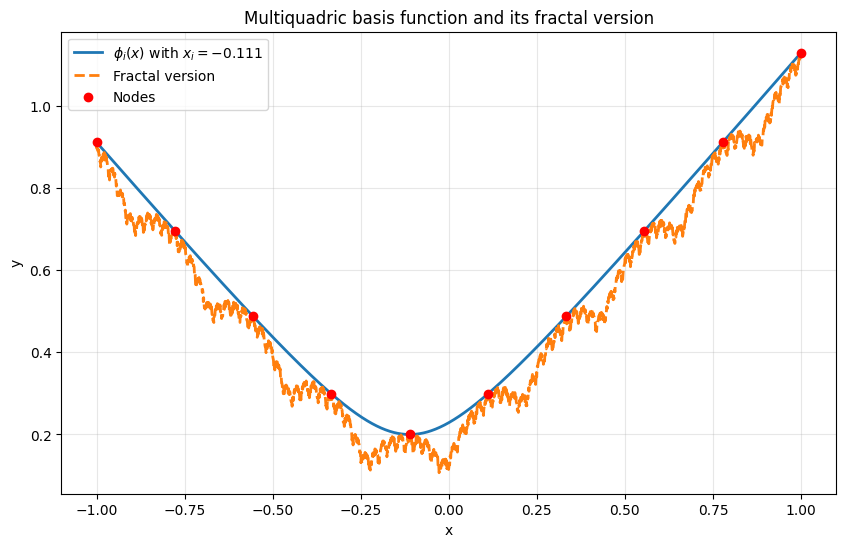

In [60]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, phi_vals, label=rf'$\phi_i(x)$ with $x_i={xi:.3f}$', linewidth=2)
plt.plot(x, fractal_vals, '--', label='Fractal version', linewidth=2)
plt.scatter(x_nodes, phi_i(x_nodes, xi, c), color='red', zorder=5, label='Nodes')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Multiquadric basis function and its fractal version')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()